# Assignment 2: Sentiment Classification with Neural Language Models

**Stage 1 - Model Development and Public Test Evaluation**

This notebook develops a sentiment classifier for movie reviews. The goal is to classify each review as:

- `0` = Negative
- `1` = Positive

The training dataset is small and imbalanced, so the model development process will consider overfitting, class imbalance, and generalization to unseen reviews.

In [1]:
import pandas as pd

train_df = pd.read_csv("train.csv")

print("Training set shape:", train_df.shape)
display(train_df.head())

Training set shape: (240, 5)


,id,text,label,label_name,source_file
0,pos_cv230_7428,"well , i'll admit when i first heard about thi...",1,positive,pos/cv230_7428.txt
1,pos_cv853_29233,my summer was recently saved by two very diffe...,1,positive,pos/cv853_29233.txt
2,pos_cv771_28665,in october of 1962 the united states found its...,1,positive,pos/cv771_28665.txt
3,pos_cv449_8785,this is a good year if you want plenty of sci-...,1,positive,pos/cv449_8785.txt
4,pos_cv130_17083,"while watching wes anderson's rushmore , it ma...",1,positive,pos/cv130_17083.txt


In [2]:
print("Class counts:")
print(train_df["label"].value_counts().sort_index())

print("\nClass percentages:")
print((train_df["label"].value_counts(normalize=True).sort_index() * 100).round(2))

Class counts:
label
0     60
1    180
Name: count, dtype: int64

Class percentages:
label
0    25.0
1    75.0
Name: proportion, dtype: float64


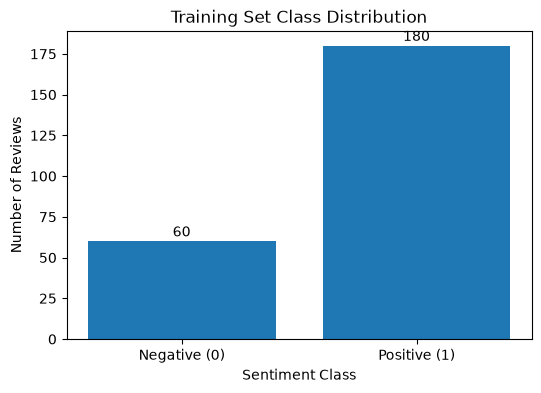

In [3]:
import matplotlib.pyplot as plt

class_counts = train_df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Negative (0)", "Positive (1)"], class_counts.values)

plt.title("Training Set Class Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Reviews")

for i, count in enumerate(class_counts.values):
    plt.text(i, count + 3, str(count), ha="center")

plt.show()

### Class Imbalance

The training set is imbalanced. There are 180 positive reviews and only 60 negative reviews. This means 75% of the training data is positive and 25% is negative.

This imbalance could make the model favor the positive class. Later in the training process, I will use methods such as class weighting and a stratified train/validation split to reduce this problem.

In [4]:
print("Missing values:")
print(train_df.isnull().sum())

Missing values:
id             0
text           0
label          0
label_name     0
source_file    0
dtype: int64


In [5]:
train_df["word_count"] = train_df["text"].str.split().str.len()

print("Review length statistics:")
print(train_df["word_count"].describe())

Review length statistics:
count     240.000000
mean      787.708333
std       364.790842
min        17.000000
25%       555.250000
50%       732.500000
75%       939.750000
max      2570.000000
Name: word_count, dtype: float64


In [6]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

token_lengths = train_df["text"].apply(
    lambda text: len(tokenizer.encode(text, add_special_tokens=True))
)

print("Token length statistics:")
print(token_lengths.describe())

print("\nReviews longer than 512 tokens:")
print((token_lengths > 512).sum())

print("\nPercentage longer than 512 tokens:")
print(round((token_lengths > 512).mean() * 100, 2), "%")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (784 > 512). Running this sequence through the model will result in indexing errors


Token length statistics:
count     240.000000
mean      896.933333
std       409.528022
min        27.000000
25%       635.500000
50%       852.500000
75%      1078.000000
max      2848.000000
Name: text, dtype: float64

Reviews longer than 512 tokens:
210

Percentage longer than 512 tokens:
87.5 %


### Review Lengths

The movie reviews are relatively long. After tokenizing the reviews with the DistilBERT tokenizer, the average review contains about 897 tokens.

DistilBERT supports a maximum sequence length of 512 tokens. In the training set, 210 out of 240 reviews (87.5%) are longer than 512 tokens.

Because most reviews are longer than the model limit, simply truncating every review from the end could remove useful sentiment information. To reduce this problem, I will use a head-and-tail truncation strategy that keeps information from both the beginning and the end of long reviews.

In [7]:
from sklearn.model_selection import train_test_split

train_split, val_split = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df["label"]
)

print("Training split size:", len(train_split))
print("Validation split size:", len(val_split))

print("\nTraining class counts:")
print(train_split["label"].value_counts().sort_index())

print("\nValidation class counts:")
print(val_split["label"].value_counts().sort_index())

Training split size: 192
Validation split size: 48

Training class counts:
label
0     48
1    144
Name: count, dtype: int64

Validation class counts:
label
0    12
1    36
Name: count, dtype: int64


In [8]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_split["label"]
)

print("Class weights:")
print("Negative class (0):", class_weights[0])
print("Positive class (1):", class_weights[1])

Class weights:
Negative class (0): 2.0
Positive class (1): 0.6666666666666666


### Train/Validation Split and Class Imbalance Handling

I split the original training data into 80% training and 20% validation data. I used a stratified split so both sets keep the same class ratio as the original dataset.

The training split contains:

- 48 negative reviews
- 144 positive reviews

The validation split contains:

- 12 negative reviews
- 36 positive reviews

To reduce the effect of the class imbalance, I calculated balanced class weights using only the training split. The negative class receives a weight of 2.0, while the positive class receives a weight of about 0.67.

These weights will be used in the loss function so errors on the smaller negative class have more influence during training.

In [9]:
MAX_LENGTH = 512
CONTENT_LENGTH = MAX_LENGTH - 2   # Leave space for [CLS] and [SEP]
HEAD_LENGTH = CONTENT_LENGTH // 2
TAIL_LENGTH = CONTENT_LENGTH - HEAD_LENGTH

print("Maximum sequence length:", MAX_LENGTH)
print("Beginning tokens kept:", HEAD_LENGTH)
print("Ending tokens kept:", TAIL_LENGTH)

Maximum sequence length: 512
Beginning tokens kept: 255
Ending tokens kept: 255


In [10]:
def head_tail_tokenize(text):
    # Tokenize without adding special tokens yet
    token_ids = tokenizer.encode(
        text,
        add_special_tokens=False,
        truncation=False
    )

    # If the review is too long, keep the beginning and the end
    if len(token_ids) > CONTENT_LENGTH:
        token_ids = token_ids[:HEAD_LENGTH] + token_ids[-TAIL_LENGTH:]

    # Add [CLS] at the beginning and [SEP] at the end
    token_ids = [tokenizer.cls_token_id] + token_ids + [tokenizer.sep_token_id]

    # Create attention mask
    attention_mask = [1] * len(token_ids)

    # Pad shorter reviews to 512 tokens
    padding_length = MAX_LENGTH - len(token_ids)

    token_ids = token_ids + [tokenizer.pad_token_id] * padding_length
    attention_mask = attention_mask + [0] * padding_length

    return {
        "input_ids": token_ids,
        "attention_mask": attention_mask
    }

In [11]:
# Find the longest review
longest_index = token_lengths.idxmax()
longest_review = train_df.loc[longest_index, "text"]

# Apply head-and-tail tokenization
test_encoding = head_tail_tokenize(longest_review)

print("Original token length:", token_lengths.loc[longest_index])
print("Final input_ids length:", len(test_encoding["input_ids"]))
print("Final attention_mask length:", len(test_encoding["attention_mask"]))
print("Active tokens:", sum(test_encoding["attention_mask"]))

Original token length: 2848
Final input_ids length: 512
Final attention_mask length: 512
Active tokens: 512


In [12]:
# Find the shortest review
shortest_index = token_lengths.idxmin()
shortest_review = train_df.loc[shortest_index, "text"]

# Apply head-and-tail tokenization
short_encoding = head_tail_tokenize(shortest_review)

print("Original token length:", token_lengths.loc[shortest_index])
print("Final input_ids length:", len(short_encoding["input_ids"]))
print("Final attention_mask length:", len(short_encoding["attention_mask"]))
print("Active tokens:", sum(short_encoding["attention_mask"]))
print("Padding tokens:", short_encoding["attention_mask"].count(0))

Original token length: 27
Final input_ids length: 512
Final attention_mask length: 512
Active tokens: 27
Padding tokens: 485


In [13]:
import torch
from torch.utils.data import Dataset

class SentimentDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["text"].tolist()
        self.labels = dataframe["label"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        encoding = head_tail_tokenize(self.texts[index])

        return {
            "input_ids": torch.tensor(encoding["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(encoding["attention_mask"], dtype=torch.long),
            "labels": torch.tensor(self.labels[index], dtype=torch.long)
        }

In [14]:
train_dataset = SentimentDataset(train_split)
val_dataset = SentimentDataset(val_split)

print("Training examples:", len(train_dataset))
print("Validation examples:", len(val_dataset))

sample = train_dataset[0]

print("\nSample input_ids shape:", sample["input_ids"].shape)
print("Sample attention_mask shape:", sample["attention_mask"].shape)
print("Sample label:", sample["labels"].item())

Training examples: 192
Validation examples: 48

Sample input_ids shape: torch.Size([512])
Sample attention_mask shape: torch.Size([512])
Sample label: 1


In [15]:
from torch.utils.data import DataLoader

BATCH_SIZE = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Batch size:", BATCH_SIZE)

Training batches: 96
Validation batches: 24
Batch size: 2


In [16]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    print("Using CPU")
    device = torch.device("cpu")

print("Device selected:", device)

PyTorch version: 2.13.0+cu130
CUDA available: True
GPU: NVIDIA GeForce GTX 1660 Ti
Device selected: cuda


In [17]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")

PyTorch version: 2.13.0+cu130
CUDA available: True
GPU: NVIDIA GeForce GTX 1660 Ti
GPU memory: 6.0 GB


In [18]:
from transformers import AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model = model.to(device)

print("Model loaded:", MODEL_NAME)
print("Number of labels:", model.config.num_labels)
print("Device:", next(model.parameters()).device)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

d:\GitHub\HamadBouarki_Assignment2_CYSE499\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\BUARK\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased
Number of labels: 2
Device: cuda:0


In [19]:
import torch.nn as nn
from torch.optim import AdamW

# Move class weights to the same device as the model
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

LEARNING_RATE = 2e-5

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Loss function: Weighted CrossEntropyLoss")
print("Class weights:", class_weights_tensor)
print("Optimizer: AdamW")
print("Learning rate:", LEARNING_RATE)

Loss function: Weighted CrossEntropyLoss
Class weights: tensor([2.0000, 0.6667], device='cuda:0')
Optimizer: AdamW
Learning rate: 2e-05


In [20]:
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix

def evaluate_model(model, data_loader):
    model.eval()

    all_predictions = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            loss = criterion(logits, labels)

            total_loss += loss.item()

            predictions = torch.argmax(logits, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_predictions)
    cm = confusion_matrix(all_labels, all_predictions)

    return avg_loss, accuracy, cm

In [22]:
from tqdm.auto import tqdm

def train_one_epoch(model, data_loader):
    model.train()

    total_loss = 0

    for batch in tqdm(data_loader, desc="Training"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        loss = criterion(logits, labels)

        loss.backward()

        # Prevent very large gradient updates
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)

In [23]:
print("Epoch 1")

train_loss = train_one_epoch(model, train_loader)

val_loss, val_accuracy, val_cm = evaluate_model(
    model,
    val_loader
)

print("\nTraining loss:", round(train_loss, 4))
print("Validation loss:", round(val_loss, 4))
print("Validation accuracy:", round(val_accuracy * 100, 2), "%")

print("\nValidation confusion matrix:")
print(val_cm)

Epoch 1


Training:   0%|          | 0/96 [00:00<?, ?it/s]


Training loss: 0.8656
Validation loss: 1.0995
Validation accuracy: 75.0 %

Validation confusion matrix:
[[ 0 12]
 [ 0 36]]


In [24]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score
)

def evaluate_model(model, data_loader):
    model.eval()

    all_predictions = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            loss = criterion(logits, labels)

            total_loss += loss.item()

            predictions = torch.argmax(logits, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_predictions)
    balanced_accuracy = balanced_accuracy_score(all_labels, all_predictions)
    macro_f1 = f1_score(all_labels, all_predictions, average="macro")
    cm = confusion_matrix(all_labels, all_predictions)

    return avg_loss, accuracy, balanced_accuracy, macro_f1, cm

In [25]:
val_loss, val_accuracy, val_balanced_accuracy, val_macro_f1, val_cm = evaluate_model(
    model,
    val_loader
)

print("Validation loss:", round(val_loss, 4))
print("Validation accuracy:", round(val_accuracy * 100, 2), "%")
print("Balanced accuracy:", round(val_balanced_accuracy * 100, 2), "%")
print("Macro F1:", round(val_macro_f1, 4))

print("\nValidation confusion matrix:")
print(val_cm)

Validation loss: 1.0995
Validation accuracy: 75.0 %
Balanced accuracy: 50.0 %
Macro F1: 0.4286

Validation confusion matrix:
[[ 0 12]
 [ 0 36]]


In [26]:
from torch.utils.data import WeightedRandomSampler

# Labels in the training split
train_labels = train_split["label"].to_numpy()

# Count each class
class_counts = np.bincount(train_labels)

# Give samples from smaller classes a higher sampling probability
sample_weights = np.array([
    1.0 / class_counts[label]
    for label in train_labels
])

generator = torch.Generator()
generator.manual_seed(SEED)

train_sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True,
    generator=generator
)

# Replace the old shuffled DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler
)

# We will use normal CrossEntropyLoss because
# class imbalance is now handled by the sampler
criterion = nn.CrossEntropyLoss()

print("Original training counts:")
print("Negative:", class_counts[0])
print("Positive:", class_counts[1])

print("\nBalanced sampler created.")
print("Training batches:", len(train_loader))
print("Loss function: CrossEntropyLoss (unweighted)")

Original training counts:
Negative: 48
Positive: 144

Balanced sampler created.
Training batches: 96
Loss function: CrossEntropyLoss (unweighted)


In [27]:
# Reset random seeds before creating a fresh model
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Reload a fresh pretrained DistilBERT classifier
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model = model.to(device)

# Use normal loss because imbalance is handled by the sampler
criterion = nn.CrossEntropyLoss()

# Create a fresh optimizer for the fresh model
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Fresh model loaded.")
print("Device:", next(model.parameters()).device)
print("Loss:", criterion)
print("Learning rate:", optimizer.param_groups[0]["lr"])

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh model loaded.
Device: cuda:0
Loss: CrossEntropyLoss()
Learning rate: 2e-05


In [28]:
print("Balanced Sampling Experiment - Epoch 1")

train_loss = train_one_epoch(model, train_loader)

val_loss, val_accuracy, val_balanced_accuracy, val_macro_f1, val_cm = evaluate_model(
    model,
    val_loader
)

print("\nTraining loss:", round(train_loss, 4))
print("Validation loss:", round(val_loss, 4))
print("Validation accuracy:", round(val_accuracy * 100, 2), "%")
print("Balanced accuracy:", round(val_balanced_accuracy * 100, 2), "%")
print("Macro F1:", round(val_macro_f1, 4))

print("\nValidation confusion matrix:")
print(val_cm)

Balanced Sampling Experiment - Epoch 1


Training:   0%|          | 0/96 [00:00<?, ?it/s]


Training loss: 0.6516
Validation loss: 0.5649
Validation accuracy: 77.08 %
Balanced accuracy: 76.39 %
Macro F1: 0.7283

Validation confusion matrix:
[[ 9  3]
 [ 8 28]]


In [29]:
import os

CHECKPOINT_DIR = "model_checkpoint"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

model.save_pretrained(CHECKPOINT_DIR)
tokenizer.save_pretrained(CHECKPOINT_DIR)

best_balanced_accuracy = val_balanced_accuracy
best_macro_f1 = val_macro_f1

print("Epoch 1 checkpoint saved.")
print("Best balanced accuracy:", round(best_balanced_accuracy * 100, 2), "%")
print("Best Macro F1:", round(best_macro_f1, 4))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1 checkpoint saved.
Best balanced accuracy: 76.39 %
Best Macro F1: 0.7283


In [30]:
print("Balanced Sampling Experiment - Epoch 2")

train_loss = train_one_epoch(model, train_loader)

val_loss, val_accuracy, val_balanced_accuracy, val_macro_f1, val_cm = evaluate_model(
    model,
    val_loader
)

print("\nTraining loss:", round(train_loss, 4))
print("Validation loss:", round(val_loss, 4))
print("Validation accuracy:", round(val_accuracy * 100, 2), "%")
print("Balanced accuracy:", round(val_balanced_accuracy * 100, 2), "%")
print("Macro F1:", round(val_macro_f1, 4))

print("\nValidation confusion matrix:")
print(val_cm)

# Save only if this epoch improves balanced accuracy
if val_balanced_accuracy > best_balanced_accuracy:
    best_balanced_accuracy = val_balanced_accuracy
    best_macro_f1 = val_macro_f1

    model.save_pretrained(CHECKPOINT_DIR)
    tokenizer.save_pretrained(CHECKPOINT_DIR)

    print("\nNew best model saved.")
else:
    print("\nEpoch 2 did not improve balanced accuracy.")
    print("Keeping the Epoch 1 checkpoint.")

print("Best balanced accuracy so far:", round(best_balanced_accuracy * 100, 2), "%")

Balanced Sampling Experiment - Epoch 2


Training:   0%|          | 0/96 [00:00<?, ?it/s]


Training loss: 0.3468
Validation loss: 0.6225
Validation accuracy: 83.33 %
Balanced accuracy: 66.67 %
Macro F1: 0.7

Validation confusion matrix:
[[ 4  8]
 [ 0 36]]

Epoch 2 did not improve balanced accuracy.
Keeping the Epoch 1 checkpoint.
Best balanced accuracy so far: 76.39 %


In [31]:
# Reload the best saved Stage 1 checkpoint
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT_DIR)

model = AutoModelForSequenceClassification.from_pretrained(
    CHECKPOINT_DIR
)

model = model.to(device)

print("Best checkpoint reloaded.")
print("Device:", next(model.parameters()).device)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Best checkpoint reloaded.
Device: cuda:0


In [32]:
val_loss, val_accuracy, val_balanced_accuracy, val_macro_f1, val_cm = evaluate_model(
    model,
    val_loader
)

print("Reloaded checkpoint validation results:")
print("Validation loss:", round(val_loss, 4))
print("Validation accuracy:", round(val_accuracy * 100, 2), "%")
print("Balanced accuracy:", round(val_balanced_accuracy * 100, 2), "%")
print("Macro F1:", round(val_macro_f1, 4))

print("\nConfusion matrix:")
print(val_cm)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (605 > 512). Running this sequence through the model will result in indexing errors


Reloaded checkpoint validation results:
Validation loss: 0.5649
Validation accuracy: 77.08 %
Balanced accuracy: 76.39 %
Macro F1: 0.7283

Confusion matrix:
[[ 9  3]
 [ 8 28]]


## Final Model Structure and Training Strategy

I used `distilbert-base-uncased` as the pretrained language model. A sequence classification head with two output classes was added for negative and positive sentiment.

Most reviews were longer than DistilBERT's 512-token limit. To handle this, I used a head-and-tail strategy that keeps 255 tokens from the beginning and 255 tokens from the end of long reviews, with the required special tokens added around them.

The original training data was split into 80% training and 20% validation data using a stratified split.

Because the training set is imbalanced, I used a weighted random sampler during training so negative examples were sampled more often. I used regular cross-entropy loss with this balanced sampling approach.

Training settings:

- Model: DistilBERT (`distilbert-base-uncased`)
- Optimizer: AdamW
- Learning rate: `2e-5`
- Batch size: `2`
- Maximum sequence length: `512`
- Random seed: `42`
- Training device: NVIDIA GPU
- Model selection metric: balanced validation accuracy

The model was trained for two epochs. Epoch 1 produced the best balanced validation accuracy. Epoch 2 increased overall accuracy but became more biased toward the positive class, so the Epoch 1 checkpoint was kept as the final model.

In [33]:
public_df = pd.read_csv("public_test.csv")

print("Public test shape:", public_df.shape)

print("\nPublic test class counts:")
print(public_df["label"].value_counts().sort_index())

display(public_df.head())

Public test shape: (400, 5)

Public test class counts:
label
0    200
1    200
Name: count, dtype: int64


,id,text,label,label_name,source_file
0,pos_cv696_29740,capsule : this is a harrowing look at a rarely...,1,positive,pos/cv696_29740.txt
1,pos_cv669_22995,"the last steve martin film i saw , the spanish...",1,positive,pos/cv669_22995.txt
2,neg_cv963_7208,"absolute power , the new film produced and dir...",0,negative,neg/cv963_7208.txt
3,pos_cv182_7281,the saint was actually a little better than i ...,1,positive,pos/cv182_7281.txt
4,pos_cv162_10424,note : some may consider portions of the follo...,1,positive,pos/cv162_10424.txt


In [34]:
public_dataset = SentimentDataset(public_df)

public_loader = DataLoader(
    public_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Public test examples:", len(public_dataset))
print("Public test batches:", len(public_loader))

Public test examples: 400
Public test batches: 200


In [35]:
public_loss, public_accuracy, public_balanced_accuracy, public_macro_f1, public_cm = evaluate_model(
    model,
    public_loader
)

print("Public Test Results")
print("-------------------")
print("Accuracy:", round(public_accuracy * 100, 2), "%")
print("Balanced accuracy:", round(public_balanced_accuracy * 100, 2), "%")
print("Macro F1:", round(public_macro_f1, 4))

print("\nConfusion matrix:")
print(public_cm)

Public Test Results
-------------------
Accuracy: 58.75 %
Balanced accuracy: 58.75 %
Macro F1: 0.5708

Confusion matrix:
[[ 78 122]
 [ 43 157]]


In [36]:
SENTIMENT_MODEL_NAME = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"

sentiment_tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_MODEL_NAME)

sentiment_model = AutoModelForSequenceClassification.from_pretrained(
    SENTIMENT_MODEL_NAME
)

sentiment_model = sentiment_model.to(device)
sentiment_model.eval()

print("Sentiment model loaded:", SENTIMENT_MODEL_NAME)
print("Device:", next(sentiment_model.parameters()).device)
print("Labels:", sentiment_model.config.id2label)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

d:\GitHub\HamadBouarki_Assignment2_CYSE499\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\BUARK\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Sentiment model loaded: distilbert/distilbert-base-uncased-finetuned-sst-2-english
Device: cuda:0
Labels: {0: 'NEGATIVE', 1: 'POSITIVE'}


In [37]:
def predict_review_with_chunks(text, model, tokenizer, max_length=512, stride=128):
    # Split a long review into overlapping chunks
    encoded = tokenizer(
        text,
        max_length=max_length,
        truncation=True,
        stride=stride,
        return_overflowing_tokens=True,
        padding=True,
        return_tensors="pt"
    )

    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    model.eval()

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probabilities = torch.softmax(outputs.logits, dim=1)

    # Average probabilities across all chunks
    average_probabilities = probabilities.mean(dim=0)

    prediction = torch.argmax(average_probabilities).item()

    return prediction, average_probabilities.cpu().numpy(), len(input_ids)

In [38]:
sample_text = val_split.iloc[0]["text"]
sample_label = val_split.iloc[0]["label"]

prediction, probabilities, num_chunks = predict_review_with_chunks(
    sample_text,
    sentiment_model,
    sentiment_tokenizer
)

print("True label:", sample_label)
print("Predicted label:", prediction)
print("Negative probability:", round(float(probabilities[0]), 4))
print("Positive probability:", round(float(probabilities[1]), 4))
print("Number of chunks:", num_chunks)

True label: 0
Predicted label: 0
Negative probability: 0.5955
Positive probability: 0.4045
Number of chunks: 2


In [39]:
from tqdm.auto import tqdm

def evaluate_chunked_model(dataframe, model, tokenizer):
    predictions = []
    labels = []

    for _, row in tqdm(
        dataframe.iterrows(),
        total=len(dataframe),
        desc="Evaluating"
    ):
        prediction, _, _ = predict_review_with_chunks(
            row["text"],
            model,
            tokenizer
        )

        predictions.append(prediction)
        labels.append(row["label"])

    accuracy = accuracy_score(labels, predictions)
    balanced_accuracy = balanced_accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average="macro")
    cm = confusion_matrix(labels, predictions)

    return accuracy, balanced_accuracy, macro_f1, cm

In [40]:
chunk_val_accuracy, chunk_val_balanced_accuracy, chunk_val_macro_f1, chunk_val_cm = evaluate_chunked_model(
    val_split,
    sentiment_model,
    sentiment_tokenizer
)

print("Pretrained SST-2 Model - Validation Results")
print("-------------------------------------------")
print("Accuracy:", round(chunk_val_accuracy * 100, 2), "%")
print("Balanced accuracy:", round(chunk_val_balanced_accuracy * 100, 2), "%")
print("Macro F1:", round(chunk_val_macro_f1, 4))

print("\nConfusion matrix:")
print(chunk_val_cm)

Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

Pretrained SST-2 Model - Validation Results
-------------------------------------------
Accuracy: 85.42 %
Balanced accuracy: 90.28 %
Macro F1: 0.8333

Confusion matrix:
[[12  0]
 [ 7 29]]


In [41]:
SST2_BASELINE_DIR = "sst2_baseline_checkpoint"

sentiment_model.save_pretrained(SST2_BASELINE_DIR)
sentiment_tokenizer.save_pretrained(SST2_BASELINE_DIR)

print("SST-2 baseline checkpoint saved.")
print("Validation accuracy:", round(chunk_val_accuracy * 100, 2), "%")
print("Balanced accuracy:", round(chunk_val_balanced_accuracy * 100, 2), "%")
print("Macro F1:", round(chunk_val_macro_f1, 4))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

SST-2 baseline checkpoint saved.
Validation accuracy: 85.42 %
Balanced accuracy: 90.28 %
Macro F1: 0.8333


In [42]:
# Load a fresh copy of the strong SST-2 baseline for fine-tuning
finetune_model = AutoModelForSequenceClassification.from_pretrained(
    SST2_BASELINE_DIR
).to(device)

# Small learning rate because this model already understands sentiment
FINETUNE_LR = 5e-6

finetune_optimizer = AdamW(
    finetune_model.parameters(),
    lr=FINETUNE_LR
)

finetune_criterion = nn.CrossEntropyLoss()

print("Fine-tuning model loaded.")
print("Device:", next(finetune_model.parameters()).device)
print("Learning rate:", FINETUNE_LR)
print("Loss function:", finetune_criterion)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Fine-tuning model loaded.
Device: cuda:0
Learning rate: 5e-06
Loss function: CrossEntropyLoss()


In [43]:
# Create a fresh balanced sampler for the SST-2 fine-tuning experiment
finetune_generator = torch.Generator()
finetune_generator.manual_seed(SEED)

finetune_sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True,
    generator=finetune_generator
)

finetune_train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=finetune_sampler
)

print("Fine-tuning training examples:", len(train_dataset))
print("Fine-tuning batches:", len(finetune_train_loader))
print("Batch size:", BATCH_SIZE)
print("Balanced sampling: enabled")

Fine-tuning training examples: 192
Fine-tuning batches: 96
Batch size: 2
Balanced sampling: enabled


In [44]:
def finetune_one_epoch(model, data_loader):
    model.train()

    total_loss = 0

    for batch in tqdm(data_loader, desc="Fine-tuning"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        finetune_optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        loss = finetune_criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        finetune_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)

In [45]:
print("SST-2 Fine-Tuning - Epoch 1")

finetune_train_loss = finetune_one_epoch(
    finetune_model,
    finetune_train_loader
)

print("\nTraining loss:", round(finetune_train_loss, 4))

SST-2 Fine-Tuning - Epoch 1


Fine-tuning:   0%|          | 0/96 [00:00<?, ?it/s]


Training loss: 0.3419


In [46]:
ft_val_accuracy, ft_val_balanced_accuracy, ft_val_macro_f1, ft_val_cm = evaluate_chunked_model(
    val_split,
    finetune_model,
    sentiment_tokenizer
)

print("Fine-Tuned SST-2 - Validation Results")
print("--------------------------------------")
print("Accuracy:", round(ft_val_accuracy * 100, 2), "%")
print("Balanced accuracy:", round(ft_val_balanced_accuracy * 100, 2), "%")
print("Macro F1:", round(ft_val_macro_f1, 4))

print("\nConfusion matrix:")
print(ft_val_cm)

print("\nBaseline comparison:")
print("Baseline accuracy:", round(chunk_val_accuracy * 100, 2), "%")
print("Baseline balanced accuracy:", round(chunk_val_balanced_accuracy * 100, 2), "%")
print("Baseline Macro F1:", round(chunk_val_macro_f1, 4))

Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

Fine-Tuned SST-2 - Validation Results
--------------------------------------
Accuracy: 89.58 %
Balanced accuracy: 87.5 %
Macro F1: 0.8648

Confusion matrix:
[[10  2]
 [ 3 33]]

Baseline comparison:
Baseline accuracy: 85.42 %
Baseline balanced accuracy: 90.28 %
Baseline Macro F1: 0.8333


In [47]:
FINAL_CANDIDATE_DIR = "sst2_finetuned_checkpoint"

finetune_model.save_pretrained(FINAL_CANDIDATE_DIR)
sentiment_tokenizer.save_pretrained(FINAL_CANDIDATE_DIR)

print("Fine-tuned candidate checkpoint saved.")
print("Validation accuracy:", round(ft_val_accuracy * 100, 2), "%")
print("Balanced accuracy:", round(ft_val_balanced_accuracy * 100, 2), "%")
print("Macro F1:", round(ft_val_macro_f1, 4))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned candidate checkpoint saved.
Validation accuracy: 89.58 %
Balanced accuracy: 87.5 %
Macro F1: 0.8648


In [48]:
reloaded_tokenizer = AutoTokenizer.from_pretrained(FINAL_CANDIDATE_DIR)

reloaded_model = AutoModelForSequenceClassification.from_pretrained(
    FINAL_CANDIDATE_DIR
).to(device)

reloaded_model.eval()

print("Fine-tuned checkpoint reloaded.")
print("Device:", next(reloaded_model.parameters()).device)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Fine-tuned checkpoint reloaded.
Device: cuda:0


In [49]:
reload_val_accuracy, reload_val_balanced_accuracy, reload_val_macro_f1, reload_val_cm = evaluate_chunked_model(
    val_split,
    reloaded_model,
    reloaded_tokenizer
)

print("Reloaded Fine-Tuned Model - Validation Results")
print("------------------------------------------------")
print("Accuracy:", round(reload_val_accuracy * 100, 2), "%")
print("Balanced accuracy:", round(reload_val_balanced_accuracy * 100, 2), "%")
print("Macro F1:", round(reload_val_macro_f1, 4))

print("\nConfusion matrix:")
print(reload_val_cm)

Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

Reloaded Fine-Tuned Model - Validation Results
------------------------------------------------
Accuracy: 89.58 %
Balanced accuracy: 87.5 %
Macro F1: 0.8648

Confusion matrix:
[[10  2]
 [ 3 33]]


In [50]:
import os
import shutil

OFFICIAL_CHECKPOINT_DIR = "model_checkpoint"

# Remove the old checkpoint
if os.path.exists(OFFICIAL_CHECKPOINT_DIR):
    shutil.rmtree(OFFICIAL_CHECKPOINT_DIR)

# Copy the final fine-tuned checkpoint into the required folder
shutil.copytree(
    FINAL_CANDIDATE_DIR,
    OFFICIAL_CHECKPOINT_DIR
)

print("Final model copied to:", OFFICIAL_CHECKPOINT_DIR)
print("\nFiles in final checkpoint:")

for filename in os.listdir(OFFICIAL_CHECKPOINT_DIR):
    print("-", filename)

Final model copied to: model_checkpoint

Files in final checkpoint:
- config.json
- model.safetensors
- tokenizer.json
- tokenizer_config.json


In [51]:
official_tokenizer = AutoTokenizer.from_pretrained("model_checkpoint")

official_model = AutoModelForSequenceClassification.from_pretrained(
    "model_checkpoint"
).to(device)

official_model.eval()

print("Official checkpoint loaded successfully.")
print("Device:", next(official_model.parameters()).device)
print("Labels:", official_model.config.id2label)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Official checkpoint loaded successfully.
Device: cuda:0
Labels: {0: 'NEGATIVE', 1: 'POSITIVE'}


In [52]:
official_public_accuracy, official_public_balanced_accuracy, official_public_macro_f1, official_public_cm = evaluate_chunked_model(
    public_df,
    official_model,
    official_tokenizer
)

print("Final Official Model - Public Test Results")
print("-------------------------------------------")
print("Accuracy:", round(official_public_accuracy * 100, 2), "%")
print("Balanced accuracy:", round(official_public_balanced_accuracy * 100, 2), "%")
print("Macro F1:", round(official_public_macro_f1, 4))

print("\nConfusion matrix:")
print(official_public_cm)

Evaluating:   0%|          | 0/400 [00:00<?, ?it/s]

Final Official Model - Public Test Results
-------------------------------------------
Accuracy: 92.25 %
Balanced accuracy: 92.25 %
Macro F1: 0.9224

Confusion matrix:
[[177  23]
 [  8 192]]


In [53]:
public_predictions = []

for _, row in tqdm(
    public_df.iterrows(),
    total=len(public_df),
    desc="Generating predictions"
):
    prediction, _, _ = predict_review_with_chunks(
        row["text"],
        official_model,
        official_tokenizer
    )

    public_predictions.append(prediction)

public_predictions_df = pd.DataFrame({
    "id": public_df["id"],
    "predicted_label": public_predictions
})

public_predictions_df.to_csv(
    "public_test_predictions.csv",
    index=False
)

print("Saved public_test_predictions.csv")
print("Shape:", public_predictions_df.shape)

display(public_predictions_df.head())

Generating predictions:   0%|          | 0/400 [00:00<?, ?it/s]

Saved public_test_predictions.csv
Shape: (400, 2)


,id,predicted_label
0,pos_cv696_29740,1
1,pos_cv669_22995,1
2,neg_cv963_7208,0
3,pos_cv182_7281,1
4,pos_cv162_10424,1


In [54]:
check_df = pd.read_csv("public_test_predictions.csv")

print("Columns:", check_df.columns.tolist())
print("Rows:", len(check_df))
print("Missing values:", check_df.isnull().sum().sum())
print("Unique predicted labels:", sorted(check_df["predicted_label"].unique().tolist()))

assert check_df.columns.tolist() == ["id", "predicted_label"]
assert len(check_df) == 400
assert check_df.isnull().sum().sum() == 0
assert set(check_df["predicted_label"].unique()).issubset({0, 1})

print("\npublic_test_predictions.csv passed all checks.")

Columns: ['id', 'predicted_label']
Rows: 400
Missing values: 0
Unique predicted labels: [0, 1]

public_test_predictions.csv passed all checks.


## Final Public Test Evaluation

The final model was evaluated on the provided `public_test.csv` using the saved `model_checkpoint/`. No training was performed on the public test set.

The final public test results were:

- Accuracy: **92.25%**
- Balanced accuracy: **92.25%**
- Macro F1 score: **0.9224**

The confusion matrix was:

| | Predicted Negative | Predicted Positive |
|---|---:|---:|
| Actual Negative | 177 | 23 |
| Actual Positive | 8 | 192 |

The model correctly classified 177 out of 200 negative reviews and 192 out of 200 positive reviews.

The final model performed substantially better than the first DistilBERT experiment. Using a sentiment-pretrained DistilBERT model, gentle fine-tuning, balanced sampling, and full-review chunking improved generalization to the balanced public test set.

## Use of AI

I used ChatGPT as a support tool during this assignment.

ChatGPT helped me:

- understand the assignment requirements,
- organize the notebook,
- explain model choices and training results,
- troubleshoot Python and PyTorch errors,
- compare different modeling approaches,

I reviewed and ran the code myself, checked the outputs, and made the final decisions about the model and training process.